### The first step to identifying good voxel regions is to visualize the density grid exported by Instant NGP

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pyvista as pv
import os

def load_volume_from_png(png_path, volume_resolution=256, slice_grid_size=32):
    """
    Load a volume from an instant-NGP exported volume PNG.
    
    Args:
        png_path: Path to the PNG file
        volume_resolution: Resolution of the volume (e.g., 256 for 256x256x256)
        slice_grid_size: Number of slices in each row/column of the PNG (e.g., 32x32 grid)
        
    Returns:
        3D numpy array representing the volume
    """
    print(f"Loading volume from: {png_path}")
    
    # Load the PNG image, limiting the image size to prevent decompression bomb attacks
    Image.MAX_IMAGE_PIXELS = None  # Disable the limit or set a higher limit if needed
    img = Image.open(png_path)
    img_array = np.array(img)
    
    # Handle different image formats (RGB vs grayscale)
    if len(img_array.shape) == 3:  # RGB image
        # Convert to grayscale by taking the first channel
        img_array = img_array[:,:,0]
    
    img_height, img_width = img_array.shape
    print(f"Image dimensions: {img_width}x{img_height}")
    
    # Calculate the size of each slice in the PNG
    slice_pixel_size = img_width // slice_grid_size
    print(f"Each slice is {slice_pixel_size}x{slice_pixel_size} pixels")
    
    # Create a 3D volume to store the data
    volume = np.zeros((volume_resolution, volume_resolution, volume_resolution), dtype=np.float32)
    
    # Calculate scaling factors if the slices need to be resized to match the volume resolution
    scale_factor = volume_resolution / slice_pixel_size
    
    # Parse the PNG into slices and arrange them into the 3D volume
    slice_counter = 0
    for y_tile in range(slice_grid_size):
        for x_tile in range(slice_grid_size):
            # Skip if we've already filled the volume
            if slice_counter >= volume_resolution:
                break
                
            # Extract the current slice
            y_start = y_tile * slice_pixel_size
            y_end = (y_tile + 1) * slice_pixel_size
            x_start = x_tile * slice_pixel_size
            x_end = (x_tile + 1) * slice_pixel_size
            
            current_slice = img_array[y_start:y_end, x_start:x_end]
            
            # Resize the slice if necessary to match the volume resolution
            if scale_factor != 1:
                from scipy.ndimage import zoom
                current_slice = zoom(current_slice, (scale_factor, scale_factor), order=1)
            
            # Place the slice in the 3D volume
            # The slices are ordered from bottom to top along the Z axis
            volume[:, :, slice_counter] = current_slice
            slice_counter += 1
            
        if slice_counter >= volume_resolution:
            break
            
    print(f"Loaded {slice_counter} Z-slices into the volume")
    
    # Normalize the volume to [0, 1] range
    volume = volume / 255.0
    
    return volume

def visualize_volume_3d(volume, opacity_mapping='linear', cmap="viridis", background_color="white"):
    """
    Create a 3D visualization of the volume data.
    
    Args:
        volume: 3D numpy array containing density values
        threshold: Minimum density value to display (for volume rendering)
        opacity_mapping: How to map density to opacity ('linear', 'sigmoid', etc.)
        cmap: Colormap to use
        background_color: Background color
        use_isosurface: Whether to use isosurfaces instead of volume rendering
        isovalues: List of values for isosurfaces (only used if use_isosurface=True)
        
    Returns:
        PyVista plotter object
    """
    
    # Create a uniform grid for the data
    dims = np.array(volume.shape) + 1
    grid = pv.ImageData()
    grid.dimensions = dims
    
    # Center the grid at the origin
    grid.origin = [-s/2 for s in volume.shape]
    grid.spacing = (1, 1, 1)
    
    grid.cell_data["density"] = volume.flatten(order='F')
    
    # Create a plotter
    plotter = pv.Plotter()
    plotter.set_background(background_color)
    plotter.add_axes()
    plotter.add_bounding_box()
    plotter.add_volume(grid, cmap=cmap, opacity=opacity_mapping, clim=[0, volume.max()])
    
    return plotter

def visualize_volume_slices(volume, z_indices=None, num_slices=4, figsize=(15, 10)):
    """
    Visualize specific Z-slices from the volume.
    
    Args:
        volume: 3D numpy array of the volume
        z_indices: List of Z indices to visualize (if None, evenly spaced slices are chosen)
        num_slices: Number of slices to show (only used if z_indices is None)
        figsize: Figure size
    """
    if z_indices is None:
        z_indices = np.linspace(0, volume.shape[2]-1, num_slices, dtype=int)
    
    fig, axes = plt.subplots(1, len(z_indices), figsize=figsize)
    if len(z_indices) == 1:
        axes = [axes]
    
    for i, z_idx in enumerate(z_indices):
        im = axes[i].imshow(volume[:, :, z_idx].T, origin='lower', cmap='viridis')
        axes[i].set_title(f'Z-Slice {z_idx}')
        fig.colorbar(im, ax=axes[i])
    
    plt.tight_layout()
    plt.show()

def transform_volume(volume, normalize=True, invert=False, threshold = 0.1):
        """
        Transform volume data by normalizing to 0-1 range and/or inverting densities.
        
        Args:
            volume: 3D numpy array containing density values
            normalize: Whether to normalize values to 0-1 range
            invert: Whether to invert the densities (low becomes high, high becomes low)
            
        Returns:
            Transformed 3D numpy array
        """
        # Create a copy to avoid modifying the original
        transformed = volume.copy()
        
        # Normalize to 0-1 range if requested
        if normalize:
            min_val = transformed.min()
            max_val = transformed.max()
            if min_val < 0 or max_val > 1:
                transformed = (transformed - min_val) / (max_val - min_val)
        
        # Invert densities if requested (make low density visible, high density transparent)
        if invert:
            transformed = 1 - transformed
        
        transformed[transformed < threshold] = 0
        return transformed

def explore_volume(png_path, volume_resolution=256, slice_grid_size=32, threshold = 0.1, invert = False):
    """
    Load and explore a volume from a PNG file.
    
    Args:
        png_path: Path to the PNG file
        volume_resolution: Resolution of the volume
        slice_grid_size: Number of slices in each row/column of the PNG
    """
    # Load the volume
    volume = load_volume_from_png(png_path, volume_resolution, slice_grid_size)
    volume = transform_volume(volume, invert=invert, threshold=threshold)
    print(f"Volume shape: {volume.shape}")
    print(f"Min density: {volume.min():.4f}, Max density: {volume.max():.4f}")
    
    # Show some slices
    print("Displaying Z-slices of the volume:")
    visualize_volume_slices(volume, z_indices=[int(volume_resolution*0.25), 
                                             int(volume_resolution*0.5), 
                                             int(volume_resolution*0.75)])
    
    # Create 3D visualization with PyVista
    print("Preparing 3D visualization...")
    plotter = visualize_volume_3d(volume, opacity_mapping='linear')
    
    # Display the 3D visualization
    print("Displaying 3D visualization (you can interact with this window):")
    plotter.show()
    
    return volume, plotter

Loading volume from: C:/Users/m.tomadakis/Documents/Graph Theory Final Project/slices/chess.density_slices_576x576x576.png
Image dimensions: 13824x13824
Each slice is 576x576 pixels
Loaded 576 Z-slices into the volume
Volume shape: (576, 576, 576)
Min density: 0.0000, Max density: 0.8941
Displaying Z-slices of the volume:


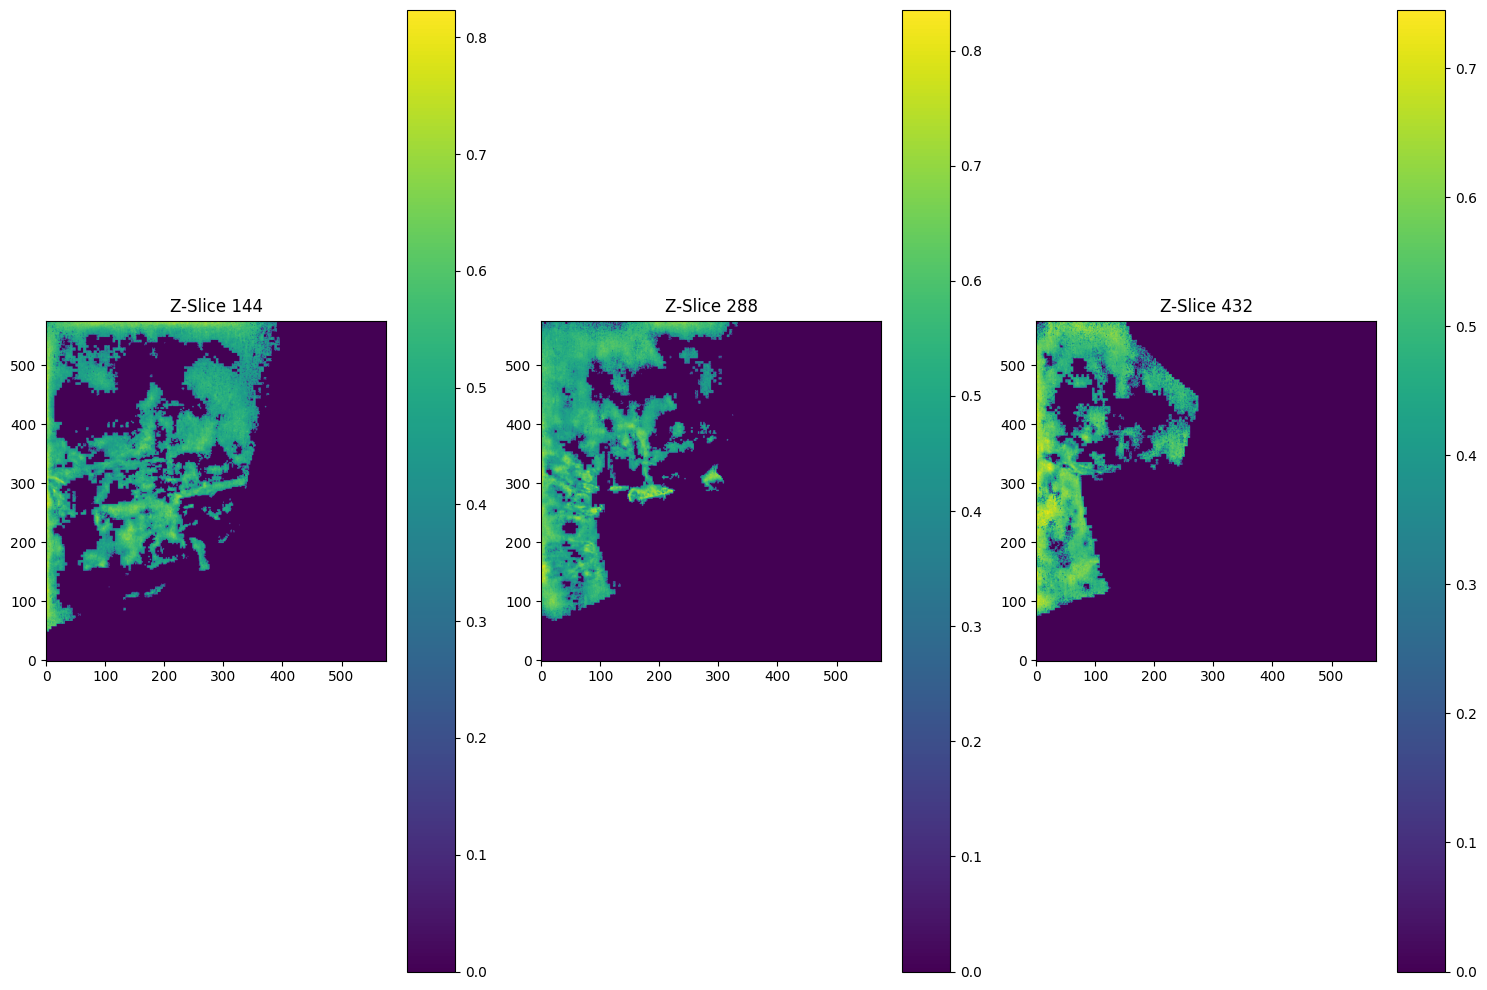

Preparing 3D visualization...
Displaying 3D visualization (you can interact with this window):


Widget(value='<iframe src="http://localhost:60476/index.html?ui=P_0x21a0a769be0_0&reconnect=auto" class="pyvis…

In [3]:
png_path = "C:/Users/m.tomadakis/Documents/Graph Theory Final Project/slices/chess.density_slices_576x576x576.png"  # Update this to your actual path

# Load and visualize the volume
# Adjust these parameters based on your specific PNG setup
volume, plotter = explore_volume(
    png_path=png_path, 
    volume_resolution=576,  # The resolution of your volume (256x256x256)
    slice_grid_size=24,      # The grid size in the PNG (32x32 slices)
    threshold=0.1,          # Minimum density value to display
    invert=False            # Invert the densities for better visibility
)

Original volume shape: (576, 576, 576)
Downsampled volume shape: (256, 256, 256)


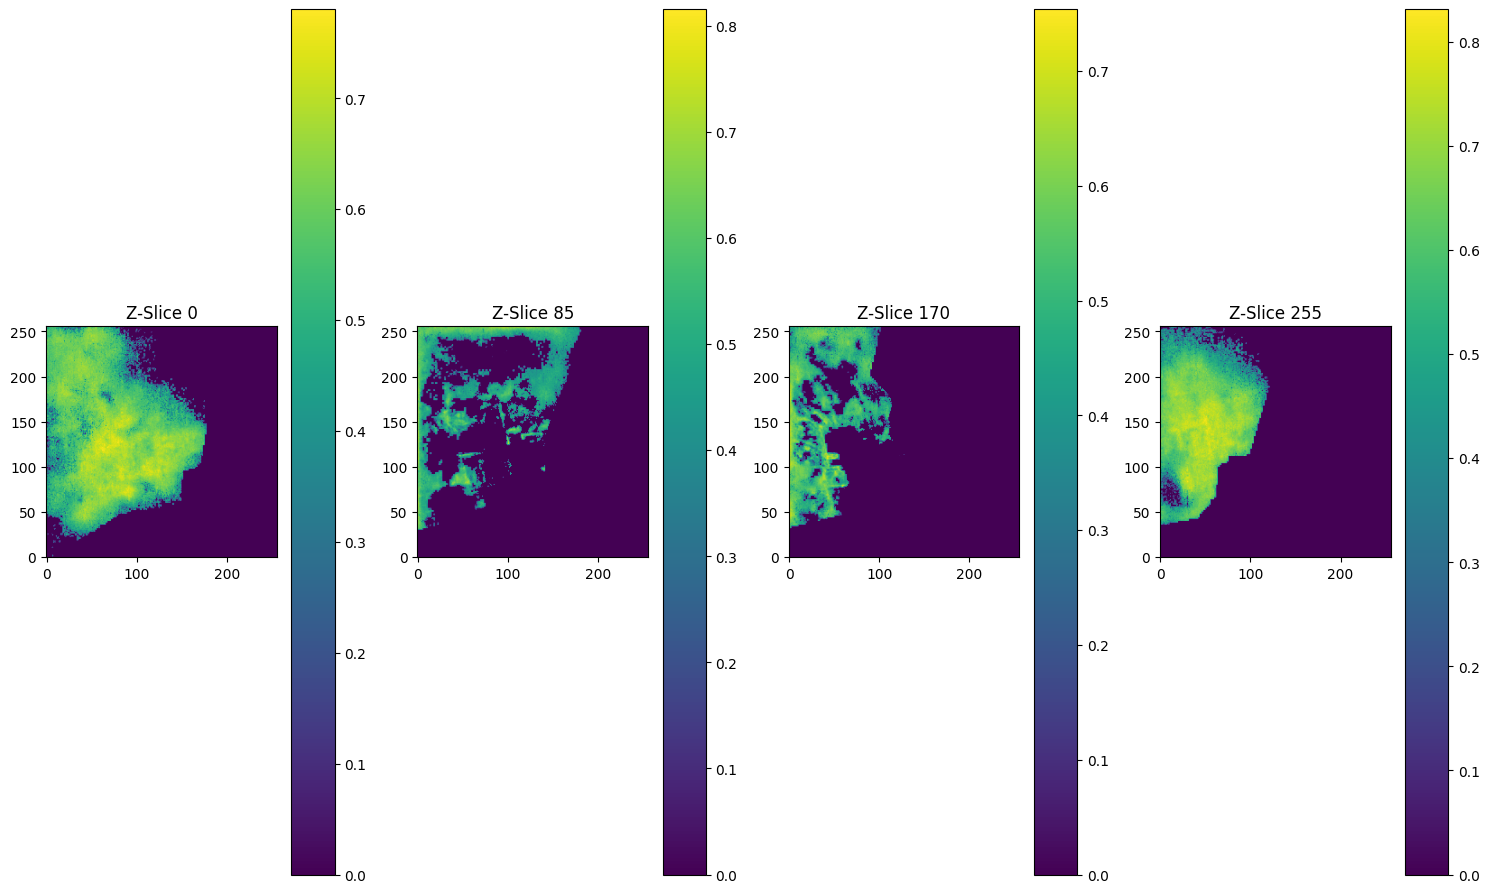

Widget(value='<iframe src="http://localhost:60476/index.html?ui=P_0x21d36a0bc50_1&reconnect=auto" class="pyvis…

In [6]:
from scipy.ndimage import zoom

# Define the desired resolution
desired_resolution = 256

# Calculate the zoom factors for each dimension
zoom_factors = (desired_resolution / volume.shape[0],
                desired_resolution / volume.shape[1],
                desired_resolution / volume.shape[2])

# Downsample the volume using zoom
downsampled_volume = zoom(volume, zoom_factors, order=1)  # order=1 for linear interpolation

print(f"Original volume shape: {volume.shape}")
print(f"Downsampled volume shape: {downsampled_volume.shape}")

# Visualize the downsampled volume
visualize_volume_slices(downsampled_volume, num_slices=4, figsize=(15, 10))

plotter = visualize_volume_3d(downsampled_volume, opacity_mapping='linear')
plotter.show()

In [11]:
import networkx as nx
from sklearn.cluster import SpectralClustering
from scipy.sparse import coo_matrix

volume=downsampled_volume

voxels = volume.flatten()
voxel_indices = np.arange(voxels.size)
valid_indices = voxel_indices[voxels > 0]
valid_voxels = voxels[voxels > 0]

def index_to_3d(index, shape):
    z = index // (shape[0] * shape[1])
    y = (index % (shape[0] * shape[1])) // shape[0]
    x = index % shape[0]
    return x, y, z

# Define the 6 neighbors for each voxel
neighbors = [
    (1, 0, 0),  # Right
    (-1, 0, 0),  # Left
    (0, 1, 0),  # Up
    (0, -1, 0),  # Down
    (0, 0, 1),  # Front
    (0, 0, -1)  # Back
]

print("Vectorized neighbor computation...")
# Vectorize neighbor computation
valid_indices_3d = np.array([index_to_3d(index, volume.shape) for index in valid_indices])  # Convert valid indices to 3D coordinates
print("Valid indices shape:", valid_indices_3d.shape)
neighbor_offsets = np.array(neighbors)  # Convert neighbor offsets to a NumPy array
print("Neighbor offsets shape:", neighbor_offsets.shape)
all_neighbor_coords = valid_indices_3d[:, np.newaxis, :] + neighbor_offsets  # Add neighbor offsets to all valid coordinates
print("All neighbor coordinates shape:", all_neighbor_coords.shape)
# Ensure the neighbor coordinates are within the volume bounds
valid_neighbors_mask = np.all((all_neighbor_coords >= 0) & (all_neighbor_coords < np.array(volume.shape)), axis=2)
print("Valid neighbors mask shape:", valid_neighbors_mask.shape)

# Convert valid neighbor coordinates back to linear indices
valid_neighbor_indices = np.array([np.ravel_multi_index(coord, volume.shape) if valid else -1
                                   for coord, valid in zip(all_neighbor_coords.reshape(-1, 3), valid_neighbors_mask.reshape(-1))]).reshape(len(valid_indices), len(neighbors))
print("Valid neighbor indices shape:", valid_neighbor_indices.shape)
# Filter out invalid neighbors (neighbors outside the volume or with density == 0)
valid_neighbors_filtered = [valid_neighbor_indices[i][np.isin(valid_neighbor_indices[i], valid_indices)] for i in range(len(valid_indices))]
print("Valid neighbors filtered shape:", len(valid_neighbors_filtered))

print("Creating sparse matrix...")
# Create a sparse matrix
row = np.repeat(np.arange(len(valid_indices)), [len(n) for n in valid_neighbors_filtered])
col = np.concatenate([np.where(valid_indices == n)[0] for neighbors in valid_neighbors_filtered for n in neighbors])
data = np.ones(len(col))  # Now the data is just ones since we're not weighting

adjacency_matrix = coo_matrix((data, (row, col)), shape=(len(valid_indices), len(valid_indices))).toarray()

print("Performing spectral clustering...")
# Perform spectral clustering on the adjacency matrix
n_clusters = 4  # Define the number of clusters

clustering = SpectralClustering(n_clusters=n_clusters, affinity="precomputed", random_state=42).fit(adjacency_matrix)

labels = clustering.labels_

print("Creating label volume...")
# Create a label volume
label_volume = np.zeros_like(volume, dtype=int)

# Assign cluster labels to the original volume
for i, index in enumerate(valid_indices):
    x, y, z = index_to_3d(index, volume.shape)
    label_volume[x, y, z] = labels[i] + 1  # cluster labels should not start from 0

print("Visualizing clustered volume...")
# Visualize the clustered volume
visualize_volume_slices(label_volume, num_slices=4, figsize=(15, 10))

# Optionally, visualize in 3D using pyvista
plotter = visualize_volume_3d(label_volume, opacity_mapping="linear", cmap="viridis")
plotter.show()

Vectorized neighbor computation...
Valid indices shape: (4602772, 3)
Neighbor offsets shape: (6, 3)
All neighbor coordinates shape: (4602772, 6, 3)
Valid neighbors mask shape: (4602772, 6)
Valid neighbor indices shape: (4602772, 6)


KeyboardInterrupt: 